# D1 - Capacità fiscale IRPEF 2019-2023

Notebook di supporto alla Discussion IRPEF su `dataciviclab`.

**Perimetro**
- anni: `2019-2023`
- livelli: `regione` e `comune`
- base dati: `irpef_capacita_fiscale_multi_anno.parquet`
- focus: differenze territoriali, ranking e confronti sintetici sui grandi comuni

**Nota metodologica**
- qui non uso popolazione
- il notebook lavora su contribuenti, reddito imponibile e medie per contribuente
- le letture comunali vanno tenute prudenti: la Discussion resta prima di tutto un confronto territoriale esplorativo


In [ ]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


pd.options.display.float_format = '{:,.2f}'.format


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'analisi').exists() and (candidate / '_out').exists():
            return candidate
    raise RuntimeError('Repo root non trovato')


REPO_ROOT = find_repo_root(Path.cwd())
DATA_PATH = REPO_ROOT / '_out' / 'data' / 'cross' / 'irpef_comunale_2019_2023' / 'irpef_capacita_fiscale_multi_anno.parquet'
ANNI = [2019, 2020, 2021, 2022, 2023]
GRANDI_COMUNI = ['ROMA', 'MILANO', 'TORINO', 'GENOVA', 'NAPOLI', 'BOLOGNA', 'PALERMO', 'FIRENZE', 'BARI']

con = duckdb.connect()
str(DATA_PATH)


## 1. Copertura del parquet multi-anno

Verifico che il file cross-year copra tutti gli anni e i due livelli territoriali attesi.


In [2]:
copertura = con.execute(
    """
    select
        anno_imposta,
        livello_territoriale,
        count(*) as righe,
        count(distinct territorio) as territori_distinti
    from read_parquet($path)
    group by 1, 2
    order by 1, 2
    """,
    {'path': str(DATA_PATH)},
).fetchdf()

copertura


,anno_imposta,livello_territoriale,righe,territori_distinti
0,2019,comune,7904,7898
1,2019,regione,22,22
2,2020,comune,7904,7898
3,2020,regione,22,22
4,2021,comune,7905,7900
5,2021,regione,22,22
6,2022,comune,7901,7896
7,2022,regione,22,22
8,2023,comune,7897,7892
9,2023,regione,22,22


## 2. Regioni: chi pesa di più e come evolve nel tempo

Parto dal livello regionale, che è il più leggibile per una prima risposta pubblica.


In [3]:
regioni_2023 = con.execute(
    """
    select
        territorio as regione,
        reddito_imponibile_totale_eur,
        numero_contribuenti,
        reddito_imponibile_medio_per_contribuente_eur,
        rank_nazionale_reddito_imponibile
    from read_parquet($path)
    where livello_territoriale = 'regione'
      and anno_imposta = 2023
    order by reddito_imponibile_totale_eur desc
    limit 10
    """,
    {'path': str(DATA_PATH)},
).fetchdf()

regioni_2023['reddito_imponibile_totale_mld'] = (regioni_2023['reddito_imponibile_totale_eur'] / 1e9).round(2)
regioni_2023


,regione,reddito_imponibile_totale_eur,numero_contribuenti,reddito_imponibile_medio_per_contribuente_eur,rank_nazionale_reddito_imponibile,reddito_imponibile_totale_mld
0,Lombardia,"201,598,099,350.00","7,542,193.00","26,729.37",1,201.60
1,Lazio,"97,805,613,962.00","4,019,025.00","24,335.66",2,97.81
2,Veneto,"89,647,361,564.00","3,766,133.00","23,803.56",3,89.65
3,Emilia Romagna,"86,591,268,968.00","3,499,851.00","24,741.42",4,86.59
4,Piemonte,"77,857,995,084.00","3,239,693.00","24,032.52",5,77.86
5,Toscana,"64,918,018,723.00","2,808,946.00","23,111.17",6,64.92
6,Campania,"62,555,657,725.00","3,323,765.00","18,820.72",7,62.56
7,Sicilia,"53,511,682,397.00","2,936,360.00","18,223.82",8,53.51
8,Puglia,"48,068,911,581.00","2,657,032.00","18,091.21",9,48.07
9,Liguria,"27,959,886,847.00","1,199,819.00","23,303.42",10,27.96


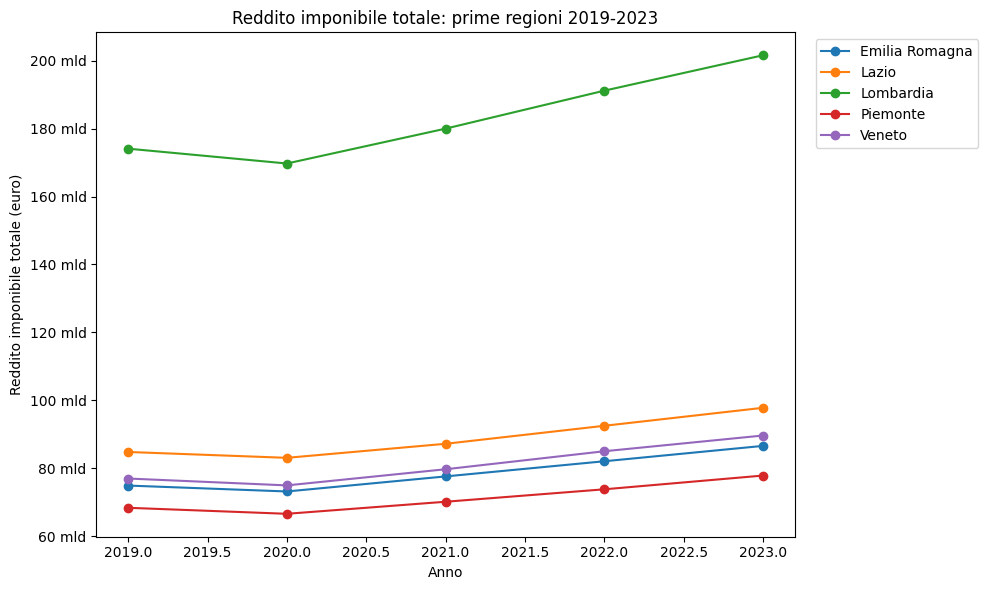

In [4]:
trend_regioni = con.execute(
    """
    select
        anno_imposta,
        territorio as regione,
        reddito_imponibile_totale_eur
    from read_parquet($path)
    where livello_territoriale = 'regione'
      and territorio in ('Lombardia', 'Lazio', 'Veneto', 'Emilia Romagna', 'Piemonte')
    order by regione, anno_imposta
    """,
    {'path': str(DATA_PATH)},
).fetchdf()

fig, ax = plt.subplots(figsize=(10, 6))
for regione, df_regione in trend_regioni.groupby('regione'):
    ax.plot(df_regione['anno_imposta'], df_regione['reddito_imponibile_totale_eur'], marker='o', label=regione)

ax.set_title('Reddito imponibile totale: prime regioni 2019-2023')
ax.set_xlabel('Anno')
ax.set_ylabel('Reddito imponibile totale (euro)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f} mld'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 3. Comuni: profilo delle grandi città

Qui tengo i principali comuni emersi dal ranking, per collegare meglio la lettura regionale a casi territoriali concreti.


In [5]:
comuni_2023 = con.execute(
    """
    select
        territorio as comune,
        regione,
        numero_contribuenti,
        reddito_imponibile_totale_eur,
        reddito_imponibile_medio_per_contribuente_eur,
        rank_nazionale_reddito_imponibile,
        rank_regionale_reddito_imponibile,
        quota_reddito_imponibile_su_regione
    from read_parquet($path)
    where livello_territoriale = 'comune'
      and anno_imposta = 2023
      and territorio in $grandi_comuni
    order by reddito_imponibile_totale_eur desc
    """,
    {'path': str(DATA_PATH), 'grandi_comuni': GRANDI_COMUNI},
).fetchdf()

comuni_2023['reddito_imponibile_totale_mld'] = (comuni_2023['reddito_imponibile_totale_eur'] / 1e9).round(2)
comuni_2023


,comune,regione,numero_contribuenti,reddito_imponibile_totale_eur,reddito_imponibile_medio_per_contribuente_eur,rank_nazionale_reddito_imponibile,rank_regionale_reddito_imponibile,quota_reddito_imponibile_su_regione,reddito_imponibile_totale_mld
0,ROMA,Lazio,"1,982,316.00","55,910,083,326.00","28,204.43",1,1,0.57,55.91
1,MILANO,Lombardia,"1,047,822.00","38,149,599,569.00","36,408.47",2,1,0.19,38.15
2,TORINO,Piemonte,"641,387.00","16,770,892,227.00","26,147.85",3,1,0.22,16.77
3,GENOVA,Liguria,"469,790.00","11,553,479,507.00","24,592.86",4,1,0.41,11.55
4,NAPOLI,Campania,"505,838.00","11,098,320,952.00","21,940.47",5,1,0.18,11.10
5,BOLOGNA,Emilia Romagna,"308,995.00","8,823,064,967.00","28,554.07",6,1,0.10,8.82
6,PALERMO,Sicilia,"367,930.00","7,998,813,165.00","21,740.04",7,1,0.15,8.00
7,FIRENZE,Toscana,"283,661.00","7,717,146,848.00","27,205.53",8,1,0.12,7.72
8,BARI,Puglia,"218,565.00","5,101,285,924.00","23,339.90",10,1,0.11,5.10


## 4. Grandi comuni con imponibile medio più alto

Questa vista ordina i grandi comuni con una platea rilevante per reddito imponibile medio per contribuente.


In [6]:
comuni_media_alta_2023 = con.execute(
    """
    select
        territorio as comune,
        regione,
        numero_contribuenti,
        reddito_imponibile_totale_eur,
        reddito_imponibile_medio_per_contribuente_eur
    from read_parquet($path)
    where livello_territoriale = 'comune'
      and anno_imposta = 2023
      and numero_contribuenti >= 50000
    order by reddito_imponibile_medio_per_contribuente_eur desc
    limit 20
    """,
    {'path': str(DATA_PATH)},
).fetchdf()

comuni_media_alta_2023['reddito_imponibile_totale_mld'] = (comuni_media_alta_2023['reddito_imponibile_totale_eur'] / 1e9).round(2)
comuni_media_alta_2023


,comune,regione,numero_contribuenti,reddito_imponibile_totale_eur,reddito_imponibile_medio_per_contribuente_eur,reddito_imponibile_totale_mld
0,MILANO,Lombardia,"1,047,822.00","38,149,599,569.00","36,408.47",38.15
1,MONZA,Lombardia,"93,953.00","3,040,573,114.00","32,362.70",3.04
2,BERGAMO,Lombardia,"92,519.00","2,889,195,120.00","31,228.13",2.89
3,PAVIA,Lombardia,"54,678.00","1,622,329,228.00","29,670.60",1.62
4,TREVISO,Veneto,"65,868.00","1,920,880,161.00","29,162.57",1.92
5,PARMA,Emilia Romagna,"151,811.00","4,348,053,303.00","28,641.23",4.35
6,PADOVA,Veneto,"161,041.00","4,603,962,237.00","28,588.76",4.60
7,BOLOGNA,Emilia Romagna,"308,995.00","8,823,064,967.00","28,554.07",8.82
8,MODENA,Emilia Romagna,"143,268.00","4,090,832,058.00","28,553.70",4.09
9,BOLZANO .BOZEN.,Trentino Alto Adige(P.A.Bolzano),"85,183.00","2,417,137,487.00","28,375.82",2.42


## Note operative

- il notebook usa il parquet cross-year nativo prodotto dal layer `cross_year`
- la lettura pubblica va tenuta stretta: regioni, grandi comuni, confronti sintetici
- senza popolazione, qui non sto ancora leggendo capacità fiscale pro capite
- un buon primo commento sotto la Discussion può appoggiarsi a regioni top, grandi comuni selezionati e 2-3 confronti difendibili sul reddito medio
